In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load the dataset
expr = pd.read_csv('TCGA.BRCA.sampleMap_HiSeqV2.gz', sep='\t')
clinical = pd.read_csv('TCGA.BRCA.sampleMap_BRCA_clinicalMatrix', sep='\t')

#Check shapes of the datasets
print(expr.shape)
print(clinical.shape)

print(expr.head())
print(clinical.head())

(20530, 1219)
(1247, 194)
      sample  TCGA-AR-A5QQ-01  TCGA-D8-A1JA-01  TCGA-BH-A0BQ-01  \
0  ARHGEF10L           9.5074           7.4346           9.3216   
1      HIF3A           1.5787           3.6607           2.7224   
2      RNF17           0.0000           0.6245           0.5526   
3      RNF10          11.3676          11.9181          11.9665   
4      RNF11          11.1292          13.5273          11.4105   

   TCGA-BH-A0BT-01  TCGA-A8-A06X-01  TCGA-A8-A096-01  TCGA-BH-A0C7-01  \
0           9.0198           9.6417           9.7665          10.0931   
1           1.3414           0.5819           0.2738           3.6090   
2           0.0000           0.0000           0.8765           0.0000   
3          13.1881          12.0036          11.8118          11.3820   
4          11.0911          11.2545          10.8554          10.7663   

   TCGA-AC-A5XU-01  TCGA-PE-A5DE-01  ...  TCGA-A7-A13E-11  TCGA-C8-A8HP-01  \
0           9.1524           9.9398  ...           9.6

In [3]:
print(expr.columns[0])
print(clinical.columns[0])
print(clinical["PAM50Call_RNAseq"].value_counts())

subset_clinical = clinical[["sampleID", "PAM50Call_RNAseq"]]
print(subset_clinical.head())   

filtered_subset_clinical = subset_clinical[subset_clinical["PAM50Call_RNAseq"].isin(["LumA", "LumB", "Basal", "Her2"])]
print(filtered_subset_clinical["PAM50Call_RNAseq"].value_counts())




sample
sampleID
PAM50Call_RNAseq
LumA      434
LumB      194
Basal     142
Normal    119
Her2       67
Name: count, dtype: int64
          sampleID PAM50Call_RNAseq
0  TCGA-3C-AAAU-01              NaN
1  TCGA-3C-AALI-01              NaN
2  TCGA-3C-AALJ-01              NaN
3  TCGA-3C-AALK-01              NaN
4  TCGA-4H-AAAK-01              NaN
PAM50Call_RNAseq
LumA     434
LumB     194
Basal    142
Her2      67
Name: count, dtype: int64


In [6]:
# Step 1 - Reload expression data fresh
expr = pd.read_csv('TCGA.BRCA.sampleMap_HiSeqV2.gz', sep='\t')

# Step 2 - Set gene names as index then transpose
expr = expr.set_index('sample')
expr = expr.T

# Step 3 - Confirm index is now sample IDs
print(expr.index[:5].tolist())
print(expr.shape)


['TCGA-AR-A5QQ-01', 'TCGA-D8-A1JA-01', 'TCGA-BH-A0BQ-01', 'TCGA-BH-A0BT-01', 'TCGA-A8-A06X-01']
(1218, 20530)


In [7]:
merged_expr_data = pd.merge(filtered_subset_clinical, expr, left_on='sampleID', right_index=True)
print(merged_expr_data.shape)

(837, 20532)


In [8]:
x = merged_expr_data.drop(columns=['sampleID', 'PAM50Call_RNAseq'])
y = merged_expr_data['PAM50Call_RNAseq']    
print(x.shape)
print(y.shape)  

(837, 20530)
(837,)


In [9]:
gene_variance = x.var()
top_2000_genes = gene_variance.nlargest(2000).index
x_top_2000 = x[top_2000_genes]
print(x_top_2000.shape)

(837, 2000)


In [11]:
from sklearn.model_selection import train_test_split    
x_train, x_test, y_train, y_test = train_test_split(x_top_2000, y, test_size=0.2, stratify=y, random_state=42)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape) 

(669, 2000)
(669,)
(168, 2000)
(168,)


In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)    

import numpy as np
print(np.mean(x_train_scaled[:, 0]))
print(np.std(x_train_scaled[:, 0]))
print(np.mean(x_test_scaled[:, 0]))
print(np.std(x_test_scaled[:, 0]))  


-2.0299324420351142e-15
0.9999999999999996
0.03996496893699625
0.99371111103207


In [17]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(x_train_scaled, y_train)
y_pred = model.predict(x_test_scaled)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       Basal       1.00      1.00      1.00        29
        Her2       1.00      0.69      0.82        13
        LumA       0.84      0.92      0.88        87
        LumB       0.77      0.69      0.73        39

    accuracy                           0.86       168
   macro avg       0.90      0.83      0.86       168
weighted avg       0.87      0.86      0.86       168



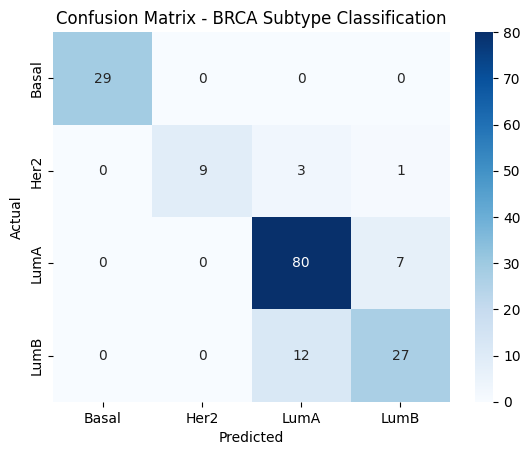

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Basal', 'Her2', 'LumA', 'LumB'], yticklabels=[ 'Basal', 'Her2', 'LumA', 'LumB'], cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - BRCA Subtype Classification')
plt.show()